# Basic Exploratory Analysis

## Objectives
* Design an hands-on lab
* Create the main parts of a hands-on lab
* Describe instructional labs and Learning Tools Interoperability (LTI) labs

## Installing required modules

In [1]:
!pip3 install pandas
!pip3 install matplotlib
!pip3 install seaborn

## Load CSV to SQLite3 with Pandas

In [2]:
import pandas as pd
import sqlite3

# Load CSV data into database
TABLE_NAME = 'MCDONALDS_NUTRITION'
data = pd.read_csv('./menu.csv')
conn = sqlite3.connect('McDonalds.db')
data.to_sql(TABLE_NAME, conn, if_exists='replace', index=False)

260

## Using pandas to explore the data

In [3]:
df = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", conn)

### View first few rows

In [4]:
df.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


### Learn about your data

In [5]:
df.describe(include= 'all')

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260,260,260,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
unique,9,260,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Coffee & Tea,Egg McMuffin,16 fl oz cup,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,95,1,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,NaN,NaN,NaN,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,NaN,NaN,NaN,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,NaN,NaN,NaN,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000


### Which food item has maximum sodium content?
#### Facts to consider for answering this question
- Main source of sodium is salt
- Average American eats 5 teaspoons/day
- Sodium mostly added during preparation
- Foods that don't taste salty may be high in sodium
- Sodium controls fluid balance in our bodies
- Too much sodium may raise blood pressure
- Target less than 2000 milligrams/day

#### Using Swarm plot

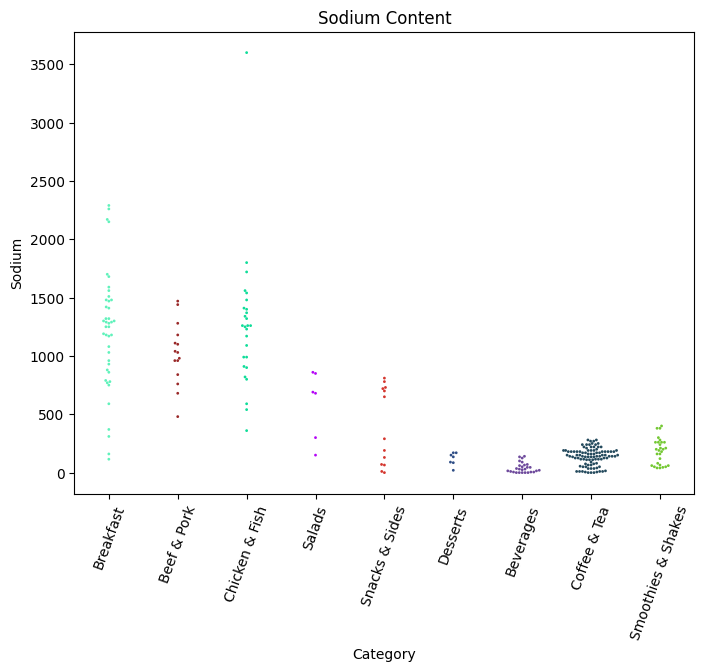

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate a random color for each unique category
unique_categories = df["Category"].unique()
np.random.seed(42)  # Ensure reproducibility
color_map = {category: np.random.rand(3,) for category in unique_categories}

# Plot using hue and disabling legend
plt.figure(figsize=(8, 6))
plot = sns.swarmplot(
    x="Category", y="Sodium", data=df, hue="Category", palette=color_map, legend=False, size=2
)
plt.setp(plot.get_xticklabels(), rotation=70)
plt.title('Sodium Content')
plt.show()

As we can see, the ***Chicken & Fish*** category has a sodium content over 3500 which is the maximum.

#### Using pandas

In [7]:
max_sodium_value = df['Sodium'].describe().max()
print(f"The maximum sodium value found is: {max_sodium_value}")

The maximum sodium value found is: 3600.0


In [8]:
# Compute the index at which this value occurs
max_sodium_value_id = df['Sodium'].idxmax()

# Find the item name associated with this id
max_sodium_item = df.at[max_sodium_value_id, 'Item']
print(max_sodium_item)

Chicken McNuggets (40 piece)


### Analyzing the relationship between the amount of protein and total fat for the menu items

#### Using a scatter plot to describe the relationship 

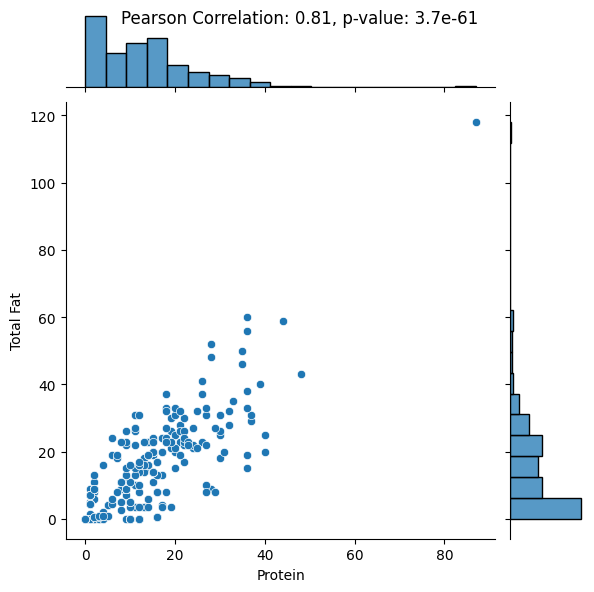

In [9]:
import sys
!{sys.executable} -m pip install scipy
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import pearsonr

plot = sns.jointplot(x="Protein", y="Total Fat", data=df)

# Compute Pearson correlation
corr, p_value = pearsonr(df["Protein"], df["Total Fat"])

# Annotate the plot
plt.suptitle(f"Pearson Correlation: {corr:.2f}, p-value: {p_value:.2g}", fontsize=12)

plt.show()

We can see that there is positive correlation between the Total fat and the protein in the menu items which is denoted by the Pearson correlation factor of 0.81.
Also we denote the presence of an outlier element at the edge of the plot.

### Using Box plots to analyze the distribution of one or more variables

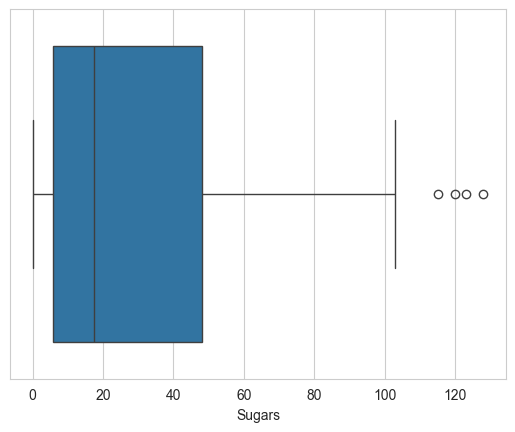

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

plot = sns.set_style("whitegrid")
ax = sns.boxplot(x=df["Sugars"])
plt.show()

* The average values of sugar in food items is around 30 grams.
* There is a few food items with extreme values of sugar around 120 grams and more.

## Summary
- SQLite3 is an in-process Python library that implements a :
    - Self-contained,
    - Serverless,
    - Zero-configuration,
    - transactional SQL database engine.
- The `pandas.read_csv` function is used to read the database csv file
- The `sqlite3.connect` function is used to connect to a database
- Pandas is used to:
    - Retrieve data from the database tables
    - Load data using `read_sql` method
    - Read data using the SQL *Select* Query
- A categorical scatterplot is created using the ***swarmplot()*** method by the searborn package.